In [20]:
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


In [2]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [3]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [4]:
df=df.select_dtypes(include='number')
df=df.drop(columns=['Accession_ID','Latitude','Longitude'])
df.head()

,Mg25,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
0,6425.217028,6.800000,7.100000,29.831934,632.671082,20.400000,-3.4,23.799999,3.716667,5.483333,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6106.090545,7.400000,6.966667,29.645391,620.901123,21.000000,-2.5,23.500000,4.400000,2.383333,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5937.667641,7.395833,8.241667,30.079075,733.808411,22.500000,-4.9,27.400000,16.350000,-0.300000,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,5936.194976,7.937500,6.741666,28.566383,631.276184,21.299999,-2.3,23.599998,8.766666,2.783333,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,5842.619693,10.337500,8.458333,32.532051,672.647827,25.100000,-0.9,26.000000,17.166666,6.133333,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [11]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [7]:
s = StandardScaler()
lr = LinearRegression()

In [10]:
estimator = Pipeline([("scaler", s),
                      ("regression", lr)])

In [13]:
kf = KFold(shuffle=True, random_state=72018, n_splits=3)

In [14]:
predictions = cross_val_predict(estimator, X, y, cv=kf)

In [15]:
r2_score(y, predictions)

0.13521485975194347

In [16]:
alphas = np.geomspace(1e-9, 1e0, num=10)
alphas

array([1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02,
       1.e-01, 1.e+00])

In [17]:
scores = []
coefs = []
for alpha in alphas:
    las = Lasso(alpha=alpha, max_iter=100000)
    
    estimator = Pipeline([
        ("scaler", s),
        ("lasso_regression", las)])

    predictions = cross_val_predict(estimator, X, y, cv = kf)
    
    score = r2_score(y, predictions)
    
    scores.append(score)

/Users/tergemina/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 28020845.813378207, tolerance: 7737.720549793629
  model = cd_fast.enet_coordinate_descent(
/Users/tergemina/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 28150759.241179913, tolerance: 7939.049604044305
  model = cd_fast.enet_coordinate_descent(
/Users/tergemina/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 27117555.84072061, tolerance: 7416.096006596549
  model = cd_fast.enet_coordinate_descent(
/Users/tergemina/opt/anaconda3/lib/python3.8/site-packages/

In [18]:
list(zip(alphas,scores))

[(1e-09, 0.13913396414847579),
 (1e-08, 0.13913396477176432),
 (1e-07, 0.13913397100456737),
 (1e-06, 0.1391340333323987),
 (1e-05, 0.13913465659755875),
 (0.0001, 0.13914088792091006),
 (0.001, 0.1392033218973866),
 (0.01, 0.13981031423789614),
 (0.1, 0.14462341101520404),
 (1.0, 0.14472449698435053)]

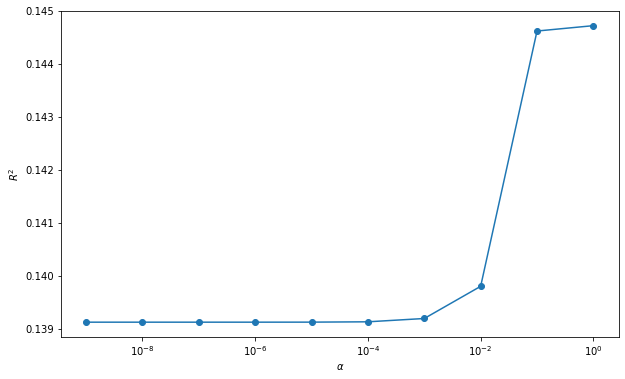

In [21]:
plt.figure(figsize=(10,6))
plt.semilogx(alphas, scores, '-o')
plt.xlabel('$\\alpha$')
plt.ylabel('$R^2$');